# Matrices de rotacion 

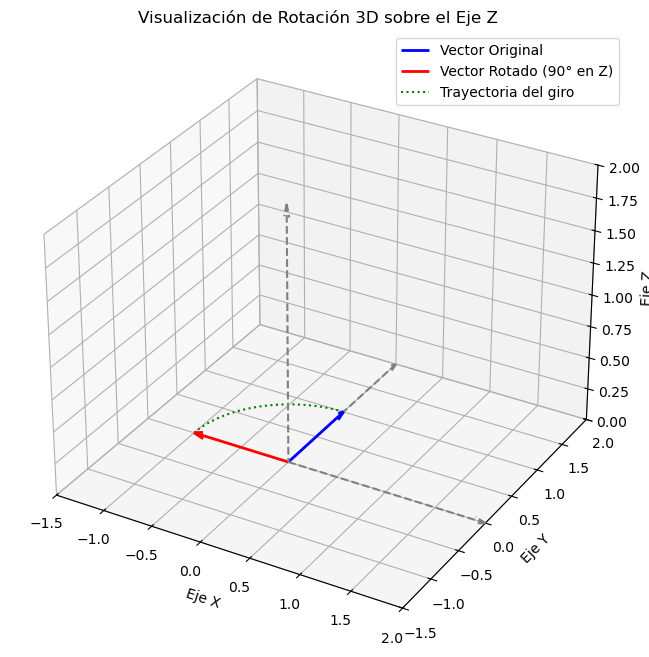

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_rotation():
    # 1. Definir el vector inicial (x, y, z)
    #v_inicial = np.array([0.0, 1.0, 0.0])
    #v_inicial = np.array([-1.0, 0.0, 0.0])
    v_inicial = np.array([0.0, 1.0, 0.0])
    
    # 2. Definir el ángulo de rotación (ej. 60 grados)
    grados = 90
    theta = np.radians(grados)
    
    # 3. Matriz de rotación alrededor del eje Z
    R_z = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])
    
    # 4. Calcular el vector rotado mediante producto punto
    v_rotado = np.dot(R_z, v_inicial)
    
    # --- Configuración de la gráfica 3D ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    origen = np.array([0, 0, 0])
    
    # Graficar los ejes principales para referencia
    ax.quiver(0, 0, 0, 2, 0, 0, color='gray', arrow_length_ratio=0.05, linestyle='dashed') # Eje X
    ax.quiver(0, 0, 0, 0, 2, 0, color='gray', arrow_length_ratio=0.05, linestyle='dashed') # Eje Y
    ax.quiver(0, 0, 0, 0, 0, 2, color='gray', arrow_length_ratio=0.05, linestyle='dashed') # Eje Z
    
    # Graficar vector original y rotado
    ax.quiver(*origen, *v_inicial, color='blue', label='Vector Original', arrow_length_ratio=0.1, linewidth=2)
    ax.quiver(*origen, *v_rotado, color='red', label=f'Vector Rotado ({grados}° en Z)', arrow_length_ratio=0.1, linewidth=2)
    
    # 5. Calcular y graficar la trayectoria del giro para visualizar el plano de rotación
    thetas = np.linspace(0, theta, 50)
    trayectoria = np.zeros((3, 50))
    for i, t in enumerate(thetas):
        R_temp = np.array([
            [np.cos(t), -np.sin(t), 0],
            [np.sin(t),  np.cos(t), 0],
            [0,          0,         1]
        ])
        trayectoria[:, i] = np.dot(R_temp, v_inicial)
        
    ax.plot(trayectoria[0, :], trayectoria[1, :], trayectoria[2, :], color='green', linestyle='dotted', label='Trayectoria del giro')
    
    # Ajustes visuales
    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-1.5, 2])
    ax.set_zlim([0, 2])
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Eje Z')
    ax.set_title('Visualización de Rotación 3D sobre el Eje Z')
    ax.legend()
    
    plt.show()

if __name__ == '__main__':
    plot_3d_rotation()

Para pasar un vector que apunta en el eje X a uno que apunte en el eje Y, se esta realizando una rotación de 90 grados (o $\pi/2$ radianes) alrededor del eje Z.Como el giro ocurre en el "piso" del espacio tridimensional (el plano $XY$), la altura ($Z$) no cambia.

1. Definición de los VectoresVector inicial ($\vec{v}_1$): Apunta en $X$, por lo tanto es $[1, 0, 0]^T$.Vector final ($\vec{v}_2$): Apunta en $Y$, por lo tanto es $[0, 1, 0]^T$.
2. La Matriz de Rotación en Z ($R_z$)Para un ángulo $\theta = 90^\circ$, sabemos que $\cos(90^\circ) = 0$ y $\sin(90^\circ) = 1$. La matriz estándar de rotación en $Z$ se simplifica así:

$$R_z(90^\circ) = \begin{bmatrix} \cos 90^\circ & -\sin 90^\circ & 0 \\ \sin 90^\circ & \cos 90^\circ & 0 \\ 0 & 0 & 1 \end{bmatrix} = \begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

3. La Operación MatricialAl multiplicar la matriz por nuestro vector original, obtenemos el nuevo vector:$$\begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} = \begin{bmatrix} (0\cdot1) + (-1\cdot0) + (0\cdot0) \\ (1\cdot1) + (0\cdot0) + (0\cdot0) \\ (0\cdot1) + (0\cdot0) + (1\cdot0) \end{bmatrix} = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}$$

Interpretación GeométricaLa primera columna de la matriz de rotación representa a dónde va a parar el vector unitario $X$ después de la transformación.En este caso, la primera columna es precisamente $[0, 1, 0]^T$, que es el eje Y.

In [3]:
import numpy as np

v_x = np.array([1, 0, 0])
# Matriz para 90 grados en Z
R = np.array([[0, -1, 0],
              [1,  0, 0],
              [0,  0, 1]])

v_y = np.dot(R, v_x)
print(f"Resultado: {v_y}") # Debería imprimir [0 1 0]

Resultado: [0 1 0]


La rotación ocurre en el plano XY, así que el eje Z — que es perpendicular a ese plano — no participa en ella. Es el eje de rotación, no un eje que se transforma.\
Esta idea es fundamental: la columna del eje de rotación siempre es (0,0,1)(0,0,1)
(0,0,1), (0,1,0)(0,1,0)
(0,1,0) o (1,0,0)(1,0,0)
(1,0,0) según alrededor de qué eje gires.

Una matriz de rotación es el mecanismo matemático que nos permite girar un vector (o un objeto completo) un ángulo específico alrededor de un eje dado, sin cambiar su longitud.En un espacio tridimensional $(x,y,z)$, estas matrices son siempre cuadradas de 3x3.\
puedes ver una matriz de rotación de dos formas: \
1. Como un operador: Tomas un vector columna $\vec{v}$ y lo premultiplicas por la matriz $R$ para obtener el vector rotado $\vec{v}_{rotado}$:$$\vec{v}_{rotado} = R \cdot \vec{v}$$
2. Como una descripción de orientación: Las columnas de una matriz de rotación describen dónde terminan los ejes unitarios originales ($X$, $Y$ y $Z$) tras la rotación.

Clave:Preserva la longitud: $\|\vec{v}_{rotado}\| = \|\vec{v}\|$. No estira ni encoge, solo gira.Es ortogonal: $R^T = R^{-1}$ (su transpuesta es igual a su inversa).Determinante: El determinante de $R$ es siempre $1$. Si fuera $-1$, incluiría una reflexión (como un espejo).

Matrices Básicas de Rotación sobre los Ejes PrincipalesAquí están las tres matrices fundamentales para rotar un ángulo $\theta$ sobre los ejes $X$, $Y$ y $Z$. Para usarlas, simplemente multiplicas la matriz correspondiente por tu vector.Rotación alrededor del Eje Z (Plano XY)$$R_z(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$Qué ocurre: $x$ e $y$ cambian, $z$ permanece constante.Rotación alrededor del Eje X (Plano YZ)$$R_x(\theta) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{bmatrix}$$Qué ocurre: $x$ permanece constante, $y$ y $z$ cambian.Rotación alrededor del Eje Y (Plano XZ)$$R_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$$

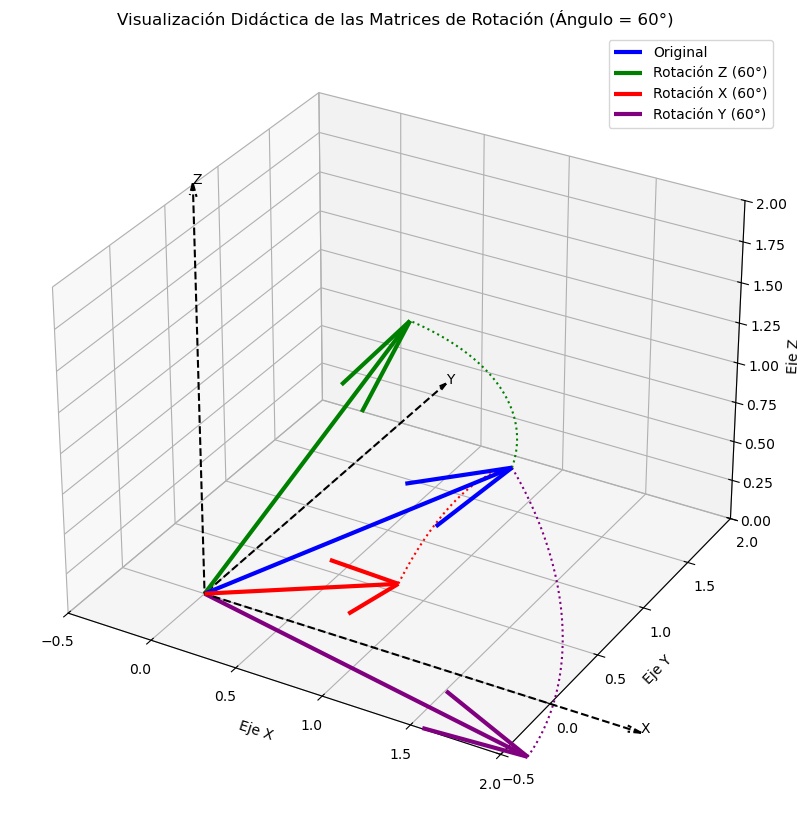

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Definición de Matrices de Rotación (Didáctico) ---

def matrix_rotation_z(theta_rad):
    """Retorna la matriz de 3x3 para rotar theta radianes en el eje Z."""
    c, s = np.cos(theta_rad), np.sin(theta_rad)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

def matrix_rotation_x(theta_rad):
    """Retorna la matriz de 3x3 para rotar theta radianes en el eje X."""
    c, s = np.cos(theta_rad), np.sin(theta_rad)
    return np.array([
        [1, 0, 0],
        [0, c, -s],
        [0, s, c]
    ])

def matrix_rotation_y(theta_rad):
    """Retorna la matriz de 3x3 para rotar theta radianes en el eje Y."""
    c, s = np.cos(theta_rad), np.sin(theta_rad)
    return np.array([
        [c,  0, s],
        [0,  1, 0],
        [-s, 0, c]
    ])

def plot_all_basic_rotations():
    # 1. Definir Vector de Prueba (x,y,z)
    v = np.array([1.5, 0.5, 1.0])
    
    # 2. Definir Ángulo de Rotación (ej. 60 grados para buena visualización)
    angle_degrees = 60
    theta = np.radians(angle_degrees)
    
    # 3. Calcular los 3 vectores rotados básicos (R * v)
    v_rot_z = np.dot(matrix_rotation_z(theta), v)
    v_rot_x = np.dot(matrix_rotation_x(theta), v)
    v_rot_y = np.dot(matrix_rotation_y(theta), v)
    
    # --- Configuración Gráfica ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    origen = np.array([0, 0, 0])
    
    # Graficar ejes principales de referencia
    ejes_len = 2.5
    ax.quiver(0,0,0, ejes_len, 0, 0, color='black', arrow_length_ratio=0.03, linestyle='dashed') # X
    ax.quiver(0,0,0, 0, ejes_len, 0, color='black', arrow_length_ratio=0.03, linestyle='dashed') # Y
    ax.quiver(0,0,0, 0, 0, ejes_len, color='black', arrow_length_ratio=0.03, linestyle='dashed') # Z
    ax.text(ejes_len, 0, 0, "X", color='black')
    ax.text(0, ejes_len, 0, "Y", color='black')
    ax.text(0, 0, ejes_len, "Z", color='black')
    
    # --- Graficar Vectores ---
    # Vector Original
    ax.quiver(*origen, *v, color='blue', label='Original', linewidth=3)
    
    # Vectores Rotados
    ax.quiver(*origen, *v_rot_z, color='green', label=f'Rotación Z ({angle_degrees}°)', linewidth=3)
    ax.quiver(*origen, *v_rot_x, color='red', label=f'Rotación X ({angle_degrees}°)', linewidth=3)
    ax.quiver(*origen, *v_rot_y, color='purple', label=f'Rotación Y ({angle_degrees}°)', linewidth=3)
    
    # --- Calcular y Graficar Trayectorias de Giro ---
    steps = 100
    thetas = np.linspace(0, theta, steps)
    
    # Trayectoria Z (Verde)
    tray_z = np.zeros((3, steps))
    for i, t in enumerate(thetas):
        tray_z[:, i] = np.dot(matrix_rotation_z(t), v)
    ax.plot(tray_z[0,:], tray_z[1,:], tray_z[2,:], color='green', linestyle='dotted')
        
    # Trayectoria X (Roja)
    tray_x = np.zeros((3, steps))
    for i, t in enumerate(thetas):
        tray_x[:, i] = np.dot(matrix_rotation_x(t), v)
    ax.plot(tray_x[0,:], tray_x[1,:], tray_x[2,:], color='red', linestyle='dotted')
        
    # Trayectoria Y (Púrpura)
    tray_y = np.zeros((3, steps))
    for i, t in enumerate(thetas):
        tray_y[:, i] = np.dot(matrix_rotation_y(t), v)
    ax.plot(tray_y[0,:], tray_y[1,:], tray_y[2,:], color='purple', linestyle='dotted')
    
    # --- Ajustes Visuales ---
    lim = 2.0
    ax.set_xlim([-0.5, lim])
    ax.set_ylim([-0.5, lim])
    ax.set_zlim([0, lim])
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Eje Z')
    ax.set_title(f'Visualización Didáctica de las Matrices de Rotación (Ángulo = {angle_degrees}°)')
    ax.legend()
    
    plt.show()

if __name__ == '__main__':
    plot_all_basic_rotations()

In [12]:
import numpy as np

def matrix_rotation_y(angle_deg):
    theta = np.radians(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    # Nota el seno positivo en la esquina superior derecha
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])

# Vector apuntando en Z puro
v_z = np.array([0, 0, 1])

# Rotamos 90 grados en Y
v_resultado = np.dot(matrix_rotation_y(90), v_z)

print(f"Vector inicial (Z): {v_z}")
print(f"Vector tras 90° en Y: {v_resultado.round(2)}") 
# Resultado: [1. 0. 0.] -> ¡Apunta a X positivo!

Vector inicial (Z): [0 0 1]
Vector tras 90° en Y: [1. 0. 0.]


El resultado de multiplicar la matriz de rotación $R_z(90^\circ)$ por su transpuesta $R_z(90^\circ)^T$ es la matriz identidad 

($I$).Matemáticamente, la operación se ve así:$$\begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} 0 & 1 & 0 \\ -1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

En álgebra lineal, las matrices de rotación pertenecen a un grupo especial llamado matrices ortogonales. 

Una propiedad fundamental de las matrices ortogonales es que su transpuesta es exactamente igual a su inversa ($R^T = R^{-1}$). 

Geométricamente, esto tiene un significado muy intuitivo:

1. Multiplicar un vector por $R_z(90^\circ)$ lo rota 90 grados en sentido antihorario.
2. Multiplicar por la transpuesta $R_z(90^\circ)^T$ equivale a aplicar la rotación inversa, es decir, lo rota -90 grados (en sentido horario).
3. Al multiplicar ambas matrices ($R \cdot R^T$), estás aplicando una rotación y luego inmediatamente deshaciéndola. El resultado neto es "no hacer nada", lo cual está representado por la matriz identidad.

calcular la inversa de una matriz computacionalmente es costoso, pero transponerla (solo intercambiar filas por columnas) es casi instantáneo.

Resultado de R * R^T:
 [[1 0 0]
 [0 1 0]
 [0 0 1]]


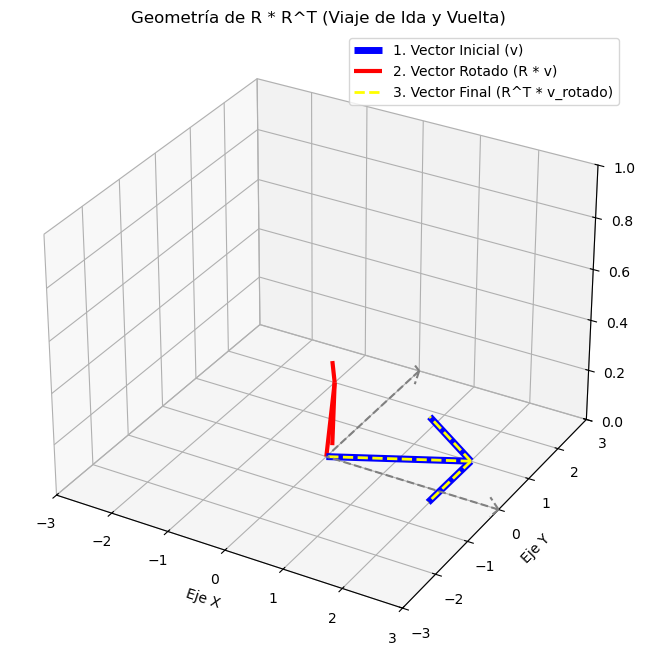

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def demostrar_ortogonalidad():
    # 1. Definir la matriz R_z para 90 grados y su transpuesta
    R_z = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ])
    R_z_T = R_z.T  # Transpuesta (equivale a la inversa, -90 grados)

    # Comprobación matemática rápida
    Identidad = np.dot(R_z, R_z_T)
    print("Resultado de R * R^T:\n", Identidad)

    # 2. Definir un vector inicial en el plano XY
    v_inicial = np.array([2.0, 1.0, 0.0])
    
    # 3. Paso de "Ida": Aplicar la rotación de 90°
    v_rotado = np.dot(R_z, v_inicial)
    
    # 4. Paso de "Vuelta": Aplicar la transpuesta al vector ya rotado
    v_final = np.dot(R_z_T, v_rotado)

    # --- Configuración Gráfica 3D ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    origen = np.array([0, 0, 0])

    # Graficar ejes
    ax.quiver(0,0,0, 3,0,0, color='gray', linestyle='dashed', arrow_length_ratio=0.05)
    ax.quiver(0,0,0, 0,3,0, color='gray', linestyle='dashed', arrow_length_ratio=0.05)

    # Graficar los vectores
    # El vector inicial y el final se superponen, los dibujamos con distinto grosor para que se noten
    ax.quiver(*origen, *v_inicial, color='blue', label='1. Vector Inicial (v)', linewidth=5)
    ax.quiver(*origen, *v_rotado, color='red', label='2. Vector Rotado (R * v)', linewidth=3)
    ax.quiver(*origen, *v_final, color='yellow', label='3. Vector Final (R^T * v_rotado)', linewidth=2, linestyle='dashed')

    # Ajustes visuales
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([0, 1])
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_title('Geometría de R * R^T (Viaje de Ida y Vuelta)')
    ax.legend()
    
    plt.show()

if __name__ == '__main__':
    demostrar_ortogonalidad()

la Matriz de Rotación en X ($R_x$) afecta a los vectores que no están en su eje. Si tenemos el vector $\vec{v} = (0, 1, 0)$ (que apunta hacia el eje Y) y aplicamos una rotación de $90^\circ$ sobre el eje X, el vector debe desplazarse en el plano YZ.

1. Análisis MatemáticoLa matriz de rotación en $X$ para $90^\circ$ ($\cos 90^\circ = 0, \sin 90^\circ = 1$) es:$$R_x(90^\circ) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{bmatrix}$$Al aplicar la operación $R_x \cdot \vec{v}$:$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$Resultado: El vector ahora apunta hacia el eje Z positivo.


Vector Inicial: [0 1 0]
Vector Resultante: [0. 0. 1.]
Dirección: Apunta hacia el eje Z


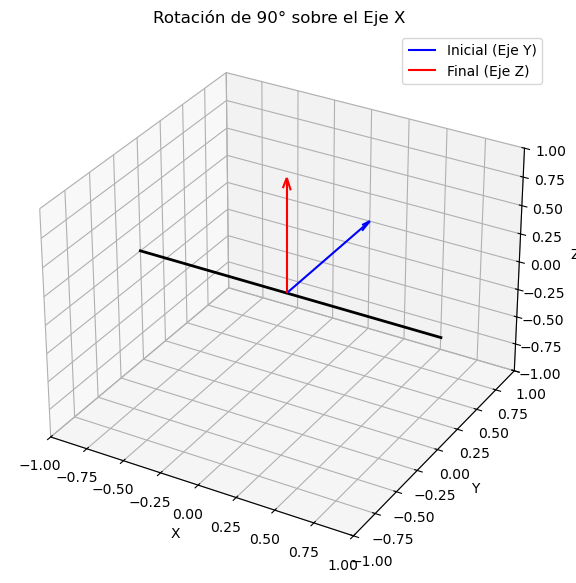

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def rotacion_x_90():
    # 1. Vector inicial (apunta a Y)
    v_inicial = np.array([0, 1, 0])
    
    # 2. Matriz Rx para 90 grados
    # cos(90)=0, sin(90)=1
    theta = np.radians(90)
    c, s = np.cos(theta), np.sin(theta)
    
    Rx = np.array([
        [1, 0,  0],
        [0, c, -s],
        [0, s,  c]
    ])
    
    # 3. Calcular vector resultante
    v_final = np.dot(Rx, v_inicial)
    
    # Limpiar valores cercanos a cero por precisión de punto flotante
    v_final = np.where(np.abs(v_final) < 1e-10, 0, v_final)
    
    print(f"Vector Inicial: {v_inicial}")
    print(f"Vector Resultante: {v_final}")
    print(f"Dirección: Apunta hacia el eje {'Z' if v_final[2] > 0 else 'Y'}")

    # --- Graficación ---
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    origen = [0, 0, 0]

    # Dibujar vectores
    ax.quiver(*origen, *v_inicial, color='blue', label='Inicial (Eje Y)', arrow_length_ratio=0.1)
    ax.quiver(*origen, *v_final, color='red', label='Final (Eje Z)', arrow_length_ratio=0.1)

    # Configuración de los ejes
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Rotación de 90° sobre el Eje X')
    ax.legend()
    
    # Dibujar el eje de rotación (X) de forma prominente
    ax.plot([-1, 1], [0, 0], [0, 0], color='black', linewidth=2, label='Eje de Rotación (X)')
    
    plt.show()

if __name__ == "__main__":
    rotacion_x_90()

# Reglas de rotación 

una transformación geométrica secuencial (como dos rotaciones seguidas) se representa multiplicando las matrices de rotación correspondientes. El orden de aplicación es de derecha a izquierda sobre el vector.

Matrices:

$R_z(90^\circ) = \begin{pmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$R_x(90^\circ) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{pmatrix}$

Validación de la No Conmutatividad ($A \cdot B \neq B \cdot A$):Para verificar si el resultado es el mismo, calcularemos ambos productos matriciales.

Orden 1: Primero X, luego Z ($R_z \cdot R_x$)Al aplicar esto a un vector $v$, la operación es $v' = R_z \cdot (R_x \cdot v)$. Matemáticamente combinamos las matrices primero:$R_z \cdot R_x = \begin{pmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{pmatrix} = \begin{pmatrix} 0 & 0 & 1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix}$

Orden 2: Primero Z, luego X ($R_x \cdot R_z$)La operación es $v'' = R_x \cdot (R_z \cdot v)$.$R_x \cdot R_z = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{pmatrix} \begin{pmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{pmatrix} = \begin{pmatrix} 0 & -1 & 0 \\ 0 & 0 & -1 \\ 1 & 0 & 0 \end{pmatrix}$

Conclusión:
$\begin{pmatrix} 0 & 0 & 1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix} \neq \begin{pmatrix} 0 & -1 & 0 \\ 0 & 0 & -1 \\ 1 & 0 & 0 \end{pmatrix}$

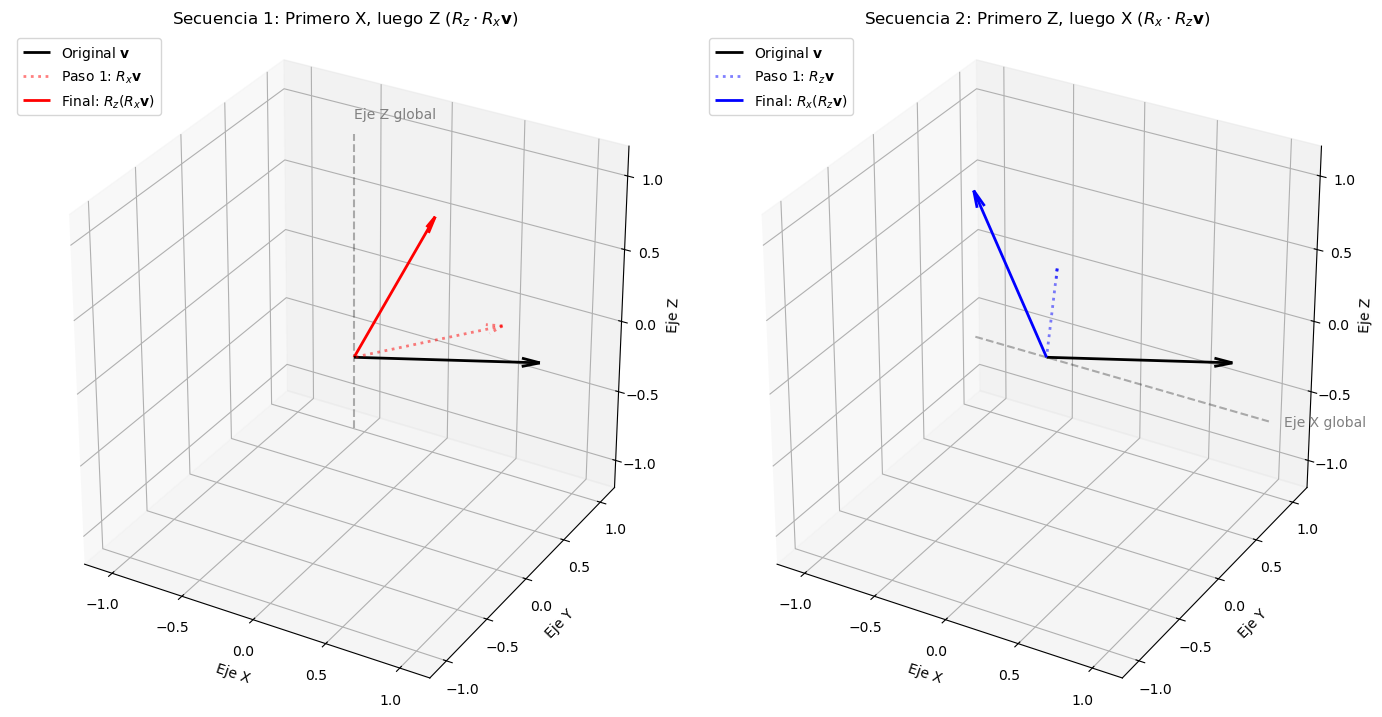

Vector original: [1.  0.5 0. ]
Resultado Final 1 (X -> Z, rojo): [0.  1.  0.5]
Resultado Final 2 (Z -> X, azul): [-0.5  0.   1. ]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Definición de Matrices de la imagen ---
Rz = np.array([[0, -1, 0],
               [1,  0, 0],
               [0,  0, 1]])

Rx = np.array([[1, 0,  0],
               [0, 0, -1],
               [0, 1,  0]])

# --- Definición de un vector arbitrario de prueba ---
# Usaremos un vector fuera de los ejes para que el efecto sea claro.
v_orig = np.array([1.0, 0.5, 0.0]) # Un vector en el plano XY

# --- Cálculos Geométricos ---

# Secuencia 1: Rz * Rx (Aplicar Rx primero, luego Rz al resultado)
# Nota: La multiplicación matricial se lee de derecha a izquierda para la aplicación.
# v_final1 = Rz @ Rx @ v_orig
v_paso1_x = np.matmul(Rx, v_orig)  # Rotación alrededor de X
v_final_rz_rx = np.matmul(Rz, v_paso1_x) # Rotación alrededor de Z del resultado anterior

# Secuencia 2: Rx * Rz (Aplicar Rz primero, luego Rx al resultado)
# v_final2 = Rx @ Rz @ v_orig
v_paso1_z = np.matmul(Rz, v_orig)  # Rotación alrededor de Z
v_final_rx_rz = np.matmul(Rx, v_paso1_z) # Rotación alrededor de X del resultado anterior

# --- Función para dibujar vectores ---
def plot_vector(ax, orig, v, color='b', label='', alpha=1, linestyle='-'):
    ax.quiver(orig[0], orig[1], orig[2], v[0], v[1], v[2],
              color=color, label=label, alpha=alpha, linestyle=linestyle,
              arrow_length_ratio=0.1, linewidth=2)

# --- Configuración de la visualización ---
fig = plt.figure(figsize=(14, 7))
origin = np.array([0, 0, 0])

# --- Subplot 1: Secuencia Rz * Rx (X -> Z) ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('Secuencia 1: Primero X, luego Z ($R_z \cdot R_x \mathbf{v}$)')

# Dibujar pasos
plot_vector(ax1, origin, v_orig, color='black', label='Original $\mathbf{v}$')
plot_vector(ax1, origin, v_paso1_x, color='red', alpha=0.5, linestyle=':', label='Paso 1: $R_x \mathbf{v}$')
plot_vector(ax1, origin, v_final_rz_rx, color='red', label='Final: $R_z (R_x \mathbf{v})$')

# Marcar eje de rotación del segundo paso para claridad
ax1.plot([0,0], [0,0], [-0.5, 1.5], 'k--', alpha=0.3) # Eje Z
ax1.text(0,0,1.6, 'Eje Z global', color='gray')

# --- Subplot 2: Secuencia Rx * Rz (Z -> X) ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title('Secuencia 2: Primero Z, luego X ($R_x \cdot R_z \mathbf{v}$)')

# Dibujar pasos
plot_vector(ax2, origin, v_orig, color='black', label='Original $\mathbf{v}$')
plot_vector(ax2, origin, v_paso1_z, color='blue', alpha=0.5, linestyle=':', label='Paso 1: $R_z \mathbf{v}$')
plot_vector(ax2, origin, v_final_rx_rz, color='blue', label='Final: $R_x (R_z \mathbf{v})$')

# Marcar eje de rotación del segundo paso para claridad
ax2.plot([-0.5, 1.5], [0,0], [0,0], 'k--', alpha=0.3) # Eje X
ax2.text(1.6,0,0, 'Eje X global', color='gray')

# --- Ajustes globales de los ejes ---
for ax in [ax1, ax2]:
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Eje Z')
    ax.legend(loc='upper left')
    # Ajustar para que las unidades sean iguales en los 3 ejes visualmente
    ax.set_box_aspect((1, 1, 1))

plt.tight_layout()
plt.show()

# Imprimir resultados numéricos para validación
print(f"Vector original: {v_orig}")
print(f"Resultado Final 1 (X -> Z, rojo): {v_final_rz_rx}")
print(f"Resultado Final 2 (Z -> X, azul): {v_final_rx_rz}")

Como las matrices resultantes son diferentes, $R_z \cdot R_x$ NO produce el mismo resultado que $R_x \cdot R_z$.

Definición Matemática: $R_{total}$

Si se tienen tres articulaciones que rotan en el orden $1 \to 2 \to 3$ sobre sus propios ejes móviles (el eje de la articulación 2 se mueve según cómo rotó la 1), la matriz resultante es:$$R_{total} = R_1 \cdot R_2 \cdot R_3$$

¿Por qué cambia el orden?

- Rotaciones Globales (Extrínsecas): Se premultiplican ($R_3 \cdot R_2 \cdot R_1$). Cada nueva rotación ocurre respecto al mundo fijo.
- Rotaciones Locales (Intrínsecas): Se posmultiplican ($R_1 \cdot R_2 \cdot R_3$). Cada nueva rotación ocurre respecto al sistema de coordenadas que "lleva puesto" el eslabón anterior.

Interpretación GeométricaImagina un brazo robótico con tres motores.
1. El motor 1 ($R_1$) gira la base.
2. El motor 2 ($R_2$) está montado sobre la base, así que su eje de giro ya cambió de orientación por culpa de $R_1$.
3. El motor 3 ($R_3$) está montado sobre el eslabón 2, así que depende de los dos giros previos.

Matemáticamente, esto se ve como una composición de marcos de referencia: $F_0 \xrightarrow{R_1} F_1 \xrightarrow{R_2} F_2 \xrightarrow{R_3} F_3$.


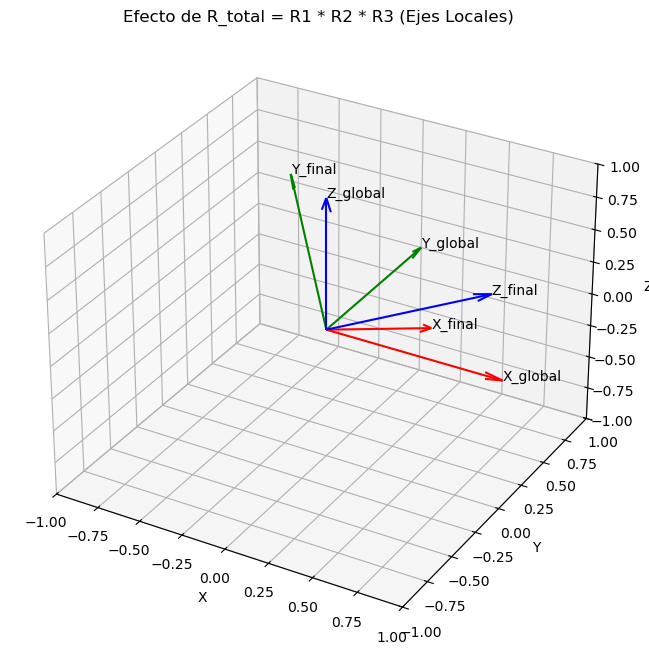

Matriz R_total Resultante:
 [[ 0.146 -0.5    0.854]
 [ 0.854  0.5    0.146]
 [-0.5    0.707  0.5  ]]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def get_rx(deg):
    theta = np.radians(deg)
    return np.array([[1, 0, 0], [0, np.cos(theta), -np.sin(theta)], [0, np.sin(theta), np.cos(theta)]])

def get_ry(deg):
    theta = np.radians(deg)
    return np.array([[np.cos(theta), 0, np.sin(theta)], [0, 1, 0], [-np.sin(theta), 0, np.cos(theta)]])

def get_rz(deg):
    theta = np.radians(deg)
    return np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])

def plot_frame(ax, R, origin=[0, 0, 0], label_suffix=""):
    """Dibuja los 3 ejes de un marco de referencia."""
    colors = ['r', 'g', 'b'] # X=rojo, Y=verde, Z=azul
    labels = ['X', 'Y', 'Z']
    for i in range(3):
        vector = R[:, i]
        ax.quiver(origin[0], origin[1], origin[2], vector[0], vector[1], vector[2], 
                  color=colors[i], arrow_length_ratio=0.1)
        ax.text(vector[0], vector[1], vector[2], f"{labels[i]}{label_suffix}")

# --- Simulación de 3 articulaciones locales ---
# Orden: Z (45°) -> X (45°) -> Y (45°) locales
R1 = get_rz(45)
R2 = get_rx(45)
R3 = get_ry(45)

# Cálculo de R_total para ejes LOCALES
R_total = R1 @ R2 @ R3

# Visualización
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Marco Global (Identidad)
plot_frame(ax, np.eye(3), label_suffix="_global")

# Marco Final tras las 3 rotaciones locales
plot_frame(ax, R_total, label_suffix="_final")

ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Efecto de R_total = R1 * R2 * R3 (Ejes Locales)')
plt.show()

print("Matriz R_total Resultante:\n", R_total.round(3))

In [18]:
import numpy as np

def crear_t_homogenea(R, d):
    """Construye una matriz 4x4 a partir de rotación 3x3 y traslación 3x1"""
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = d
    return T

# --- Eslabón 1: Rotación de 90° en Z (Sin traslación inicial) ---
theta = np.radians(90)
R01 = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
])
d01 = np.array([0, 0, 0])
T01 = crear_t_homogenea(R01, d01)

# --- Eslabón 2: Traslación de 2 unidades en su eje X LOCAL (Sin rotación extra) ---
R12 = np.eye(3) # No rota respecto al anterior
d12 = np.array([2, 0, 0]) # Camina 2 unidades en su propio X
T12 = crear_t_homogenea(R12, d12)

# --- TRANSFORMACIÓN TOTAL ---
# T02 = T01 * T12
T02 = np.matmul(T01, T12)

print("Matriz T01 (Rotación):\n", T01)
print("\nMatriz T12 (Traslación):\n", T12)
print("\nMatriz T02 (Efecto Combinado):\n", T02)

# Validemos con un punto en el origen del eslabón 2
P2 = np.array([0, 0, 0, 1]) # El 'codo' o extremo del robot
P0 = np.dot(T02, P2)

print(f"\nPosición del extremo en el marco global (0): {P0[:3]}")

Matriz T01 (Rotación):
 [[ 6.123234e-17 -1.000000e+00  0.000000e+00  0.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

Matriz T12 (Traslación):
 [[1. 0. 0. 2.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Matriz T02 (Efecto Combinado):
 [[ 6.1232340e-17 -1.0000000e+00  0.0000000e+00  1.2246468e-16]
 [ 1.0000000e+00  6.1232340e-17  0.0000000e+00  2.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]

Posición del extremo en el marco global (0): [1.2246468e-16 2.0000000e+00 0.0000000e+00]


In [19]:
import numpy as np

def dh_matrix(theta, d, a, alpha):
    """Retorna la matriz de DH estándar para un eslabón."""
    th = np.radians(theta)
    al = np.radians(alpha)
    return np.array([
        [np.cos(th), -np.sin(th)*np.cos(al),  np.sin(th)*np.sin(al), a*np.cos(th)],
        [np.sin(th),  np.cos(th)*np.cos(al), -np.cos(th)*np.sin(al), a*np.sin(th)],
        [0,           np.sin(al),             np.cos(al),            d],
        [0,           0,                      0,                     1]
    ])

def forward_kinematics_spherical(q1, q2, d3):
    # Parámetros DH simplificados para un robot esférico típico
    # T01: Rotación en Z (Cintura)
    T01 = dh_matrix(q1, 0, 0, 90)
    
    # T12: Rotación en Z local (Elevación) tras el giro de 90 en alpha
    T12 = dh_matrix(q2, 0, 0, 90)
    
    # T23: Desplazamiento prismático en el nuevo eje Z
    T23 = dh_matrix(0, d3, 0, 0)
    
    # Transformación Total: Encadenamiento de los 3 bloques
    T03 = T01 @ T12 @ T23
    
    return T01, T12, T23, T03

# Ejemplo: Cintura 45°, Elevación 45°, Extensión 1 metro
q1, q2, d3 = 45, 45, 1.0
T1, T2, T3, T_final = forward_kinematics_spherical(q1, q2, d3)

print(f"Posición del efector final (x, y, z): {T_final[:3, 3].round(3)}")
print(f"\nMatriz de Transformación Total T03:\n{T_final.round(3)}")

Posición del efector final (x, y, z): [ 0.5    0.5   -0.707]

Matriz de Transformación Total T03:
[[ 0.5    0.707  0.5    0.5  ]
 [ 0.5   -0.707  0.5    0.5  ]
 [ 0.707  0.    -0.707 -0.707]
 [ 0.     0.     0.     1.   ]]


In [25]:
import numpy as np

def calcular_matriz_dh(theta_deg, d, a, alpha):
    theta = np.radians(alpha)
    alpha = np.radians(alpha)
    
    # Matriz DH Estándar
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),                np.cos(alpha),               d],
        [0,              0,                            0,                           1]
    ])

# Si solo variamos d (desplazamiento en Z) y theta (rotación en Z)
a=0 
alpha=0 
matriz = calcular_matriz_dh(theta_deg=45, d=10, a=0, alpha=0)
print(f"Matriz con theta=45° y d=10:\n{matriz.round(2)}")

Matriz con theta=45° y d=10:
[[ 1. -0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0.  0.  1. 10.]
 [ 0.  0.  0.  1.]]
